IMPORT DATASET

In [1]:
import pandas as pd

df_first = pd.read_csv("hasil_prediksi_2500_indobert.csv")

df_first["sentiment"].value_counts()

sentiment
0    1618
2     804
1      78
Name: count, dtype: int64

In [2]:
texts = df_first["processed_text"].tolist()
labels = df_first["sentiment"].tolist()

IMPORT LIBRARY

In [3]:
import numpy as np
import pandas as pd
import torch

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score

from transformers import(
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer

)

SPLIT DATA

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    texts,
    labels,
    test_size=0.25,
    random_state=42,
    stratify=labels
)

In [5]:
print(pd.Series(y_train).value_counts())
print(pd.Series(y_test).value_counts())

0    1213
2     603
1      59
Name: count, dtype: int64
0    405
2    201
1     19
Name: count, dtype: int64


In [6]:
Model = "indobenchmark/indobert-base-p1"

tokenizer = AutoTokenizer.from_pretrained(Model)

In [7]:
train_encodings = tokenizer(
    X_train,
    truncation=True,
    padding=True,
    max_length=128
)

test_encodings = tokenizer(
    X_test,
    truncation=True,
    padding=True,
    max_length=128
)


In [8]:
class SentimentDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):

        item = {
            key: torch.tensor(val[idx])
            for key, val in self.encodings.items()
        }

        item["labels"] = torch.tensor((self.labels[idx]))

        return item
    
    def __len__(self):
        return len(self.labels)


In [9]:
train_dataset = SentimentDataset(
    train_encodings,
    y_train
)

test_dataset = SentimentDataset(
    test_encodings,
    y_test
)

In [10]:
model = AutoModelForSequenceClassification.from_pretrained(
    Model,
    num_labels=3
)

def compute_metric(eval_pred):
    logits, labels = eval_pred

    prediction = np.argmax(logits, axis=-1)

    acc = accuracy_score(labels, prediction)

    return {
        "accuracy":acc
    }

[transformers] You passed `num_labels=3` which is incompatible to the `id2label` map of length `5`.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p1
Key               | Status  | 
------------------+---------+-
classifier.weight | MISSING | 
classifier.bias   | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [11]:
training_args = TrainingArguments(
    output_dir="./indobert_sentiment",

    eval_strategy="epoch",

    save_strategy="epoch",

    num_train_epochs=3,

    per_device_train_batch_size=4,

    per_device_eval_batch_size=4,

    learning_rate=2e-5,

    weight_decay=0.01,

    load_best_model_at_end=True,

    metric_for_best_model="accuracy",

    logging_steps=50
)

In [12]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metric
)

In [13]:
trainer.train()

c:\Users\Satri\Downloads\dataset gambar\GITHUB\.venv\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy
1,0.345158,0.346526,0.897600
2,0.175734,0.441970,0.910400
3,0.002487,0.413814,0.931200


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

c:\Users\Satri\Downloads\dataset gambar\GITHUB\.venv\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

c:\Users\Satri\Downloads\dataset gambar\GITHUB\.venv\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=1407, training_loss=0.18933406821485177, metrics={'train_runtime': 2704.073, 'train_samples_per_second': 2.08, 'train_steps_per_second': 0.52, 'total_flos': 370003243680000.0, 'train_loss': 0.18933406821485177, 'epoch': 3.0})

In [14]:
predictions = trainer.predict(test_dataset)

y_pred = np.argmax(
    predictions.predictions,
    axis=1
)

c:\Users\Satri\Downloads\dataset gambar\GITHUB\.venv\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


In [15]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "negative",
            "positive",
            "neutral"
        ]
    )
)

              precision    recall  f1-score   support

    negative       0.96      0.95      0.95       405
    positive       0.75      0.79      0.77        19
     neutral       0.90      0.91      0.90       201

    accuracy                           0.93       625
   macro avg       0.87      0.88      0.88       625
weighted avg       0.93      0.93      0.93       625



In [16]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    y_pred
)

print(cm)

[[385   1  19]
 [  3  15   1]
 [ 15   4 182]]


In [17]:
df_pred = pd.read_csv("full_labeling.csv")

In [18]:
new_encodings = tokenizer(
    df_pred["processed_text"].tolist(),
    truncation=True,
    padding=True,
    max_length=128
)

In [19]:
import torch

class PredictionDataset(torch.utils.data.Dataset):
    def __init__(self, encodings):
        self.encodings = encodings

    def __getitem__(self, idx):
        return {
            key: torch.tensor(val[idx])
            for key, val in self.encodings.items()
        }

    def __len__(self):
        return len(self.encodings["input_ids"])

In [20]:
pred_dataset = PredictionDataset(new_encodings)

In [21]:
predictions = trainer.predict(pred_dataset)

c:\Users\Satri\Downloads\dataset gambar\GITHUB\.venv\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


In [22]:
import numpy as np

pred_labels = np.argmax(
    predictions.predictions,
    axis=1
)

In [23]:
df_pred["sentiment"] = pred_labels

In [24]:
label_map = {
    0: "negatif",
    1: "positif",
    2: "netral"
}

df_pred["sentiment_text"] = (
    df_pred["sentiment"]
    .map(label_map)
)

In [35]:
df_pred.to_csv(
    "18k_done_sentiment_IndoBert.csv",
    index=False
)

In [26]:
df_pred["sentiment_text"].value_counts()

sentiment_text
negatif    12013
netral      5493
positif      587
Name: count, dtype: int64

CLOUDWORD INDOBERT

In [27]:
from sklearn.feature_extraction.text import CountVectorizer

cv = CountVectorizer()

X_neg = cv.fit_transform(
    df_pred[df_pred["sentiment_text"]=="negatif"]["processed_text"]
    )

neg_freq = pd.DataFrame({
    "word": cv.get_feature_names_out(),
    "freq": X_neg.sum(axis=0).A1
})

neg_freq.sort_values("freq", ascending=False).head(50)



,word,freq
24560,yang,7659
23228,tidak,5626
4763,dan,5481
5069,di,5406
8910,indonesia,3339
9008,ini,2717
15716,negara,2656
12774,makan,2421
20133,saja,2350
9277,itu,2333


In [29]:
custom_stopwords = [
    "yang",
    "tidak",
    "di",
    "dan",
    "ini",
    "itu",
    "sudah",
    "saja",
    "dari",
    "kalau",
    "ada",
    "bisa",
    "tapi",
    "nya",
    "ke",
    "jadi",
    "karena",
    "lagi",
    "naik",
    "dengan",
    "untuk",
    "akan",
    "semua",
    "sama",
    "juga",
    "lebih",
    "lain",
    "pada",
    "masih",
    "ya",
    "apa",
    "saya",
    "mau"
]

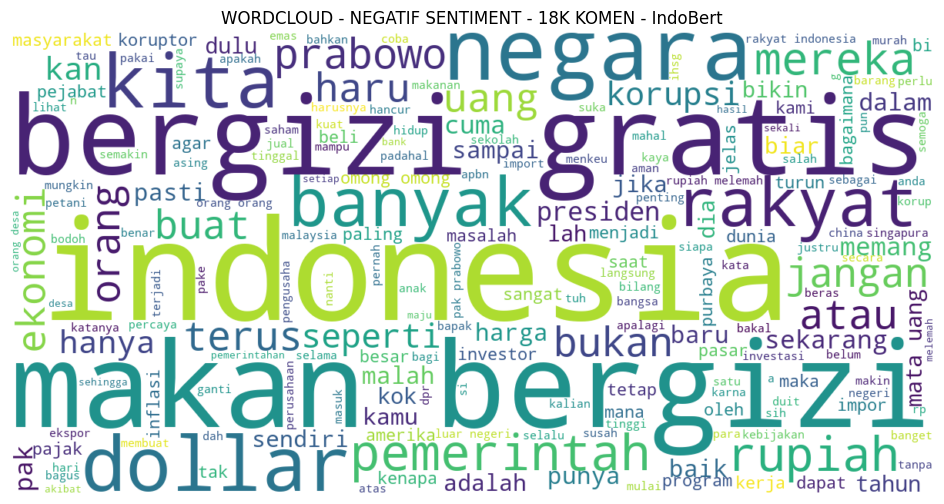

In [31]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

negatif_text = " ".join(
    df_pred[df_pred["sentiment_text"]== 'negatif']["processed_text"]

)

wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="white",
    stopwords=custom_stopwords
).generate(negatif_text)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("WORDCLOUD - NEGATIF SENTIMENT - 18K KOMEN - IndoBert")
plt.show()

In [33]:
from sklearn.feature_extraction.text import CountVectorizer

cv = CountVectorizer()

X_pos = cv.fit_transform(
    df_pred[df_pred["sentiment_text"]=="positif"]["processed_text"]
    )

pos_freq = pd.DataFrame({
    "word": cv.get_feature_names_out(),
    "freq": X_pos.sum(axis=0).A1
})

pos_freq.sort_values("freq", ascending=False).head(50)



,word,freq
414,dan,310
696,indonesia,281
2190,yang,193
1828,semoga,178
445,di,119
1449,pak,113
2132,untuk,97
708,ini,90
940,kita,80
1400,negara,68


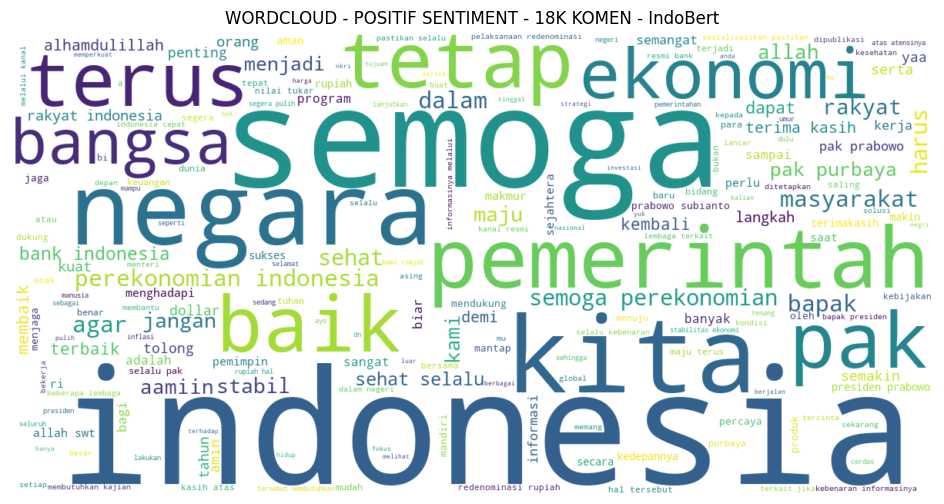

In [34]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

positif_text = " ".join(
    df_pred[df_pred["sentiment_text"]== 'positif']["processed_text"]

)

wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="white",
    stopwords=custom_stopwords
).generate(positif_text)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("WORDCLOUD - POSITIF SENTIMENT - 18K KOMEN - IndoBert")
plt.show()